![logo](../../../.././docs/images/Logo_Destination_Earth_Colours.png)

## Using earthkit with the Destination Earth Climate Digital Twins

This notebook introduces the [earthkit ecosystem](https://earthkit.ecmwf.int/) and demonstrates how to retrieve, inspect, and visualise a snapshot of Destination Earth Climate DT data using the [Polytope](https://polytope.readthedocs.io/en/latest/) API.

**What you will learn**
- How to build a Polytope request and pull data from the Climate DT stream
- How to access and explore data with `earthkit.data`
- How to make quick global and regional maps with `earthkit.plots`
- How to regrid from the native HEALPix grid to a regular latitude-longitude grid with `earthkit.geo`

### Setup

The earthkit ecosystem is a set of focused packages that work well together but can also be used
independently.  Here we import the four we need for this notebook:

This notebook uses the following components of earthkit:

<div align="center">
  <br>
  <a href="https://earthkit-data.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-data-light.svg" alt="earthkit-data" width="200">
  </a>
  <a href="https://earthkit-plots.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-plots-light.svg" alt="earthkit-plots" width="200">
  </a>
  <a href="https://earthkit-geo.readthedocs.io/en/latest/" target="_blank" style="display:inline-block; margin: 0 15px;">
    <img src="https://raw.githubusercontent.com/ecmwf/logos/refs/heads/main/logos/earthkit/earthkit-geo-light.svg" alt="earthkit-geo" width="200">
  </a>
</div>

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp
import earthkit.geo as ekg

### Retrieving data from the Climate DT

To retrieve data from the Destination Earth Climate DT, we will be using [Polytope](https://polytope.readthedocs.io/en/latest/). We won't go into too much detail here - see the other Climate DT notebooks in this repository.

When accessing data with [Polytope using earthkit-data](https://earthkit-data.readthedocs.io/en/latest/concepts/inputs/from_source.html#polytope), we use the `from_source()` method with the following arguments:
- The source type (`"polytope"`)
- The data collection (`"destination-earth"`)
- The request payload, as a dictionary
- The address - the location of the data and the polytope workers

The data arrives as GRIB, which we can transform into a *fieldlist* - an ordered collection of
individual GRIB fields that earthkit can index, filter, and convert.

In [2]:
request = {
    'activity': 'projections',   # CMIP activity: SSP scenario projections (vs. 'baseline' historical)
    'class': 'd1',               # DestinE data class
    'dataset': 'climate-dt',     # dataset family
    'date': '20260526',          # date index
    'experiment': 'SSP3-7.0',    # experiment/scenario (middle-of-the-road high emissions)
    'expver': '0001',            # experiment version (operations / research exp.)
    'generation': '2',           # dataset generation
    'levtype': 'sfc',            # vertical level type: surface fields
    'model': 'IFS-NEMO',         # coupled atmosphere-ocean model
    'param': '151/165/166/167',  # parameter IDs: MSL pressure, 10m U-wind, 10m V-wind, 2m temperature
    'realization': '1',          # initial-condition run
    'resolution': 'standard',    # quick-view ('standard') or full ('high') resolution
    'stream': 'clte',            # climate hourly time-step stream
    'time': '0100',              # time index
    'type': 'fc'                 # forecast fields
}

data = ekd.from_source(
    "polytope",
    "destination-earth",
    request,
    address="polytope.mn5.apps.dte.destination-earth.eu",
    stream=False,
).to_fieldlist()

# ls() prints a compact summary table: one row per GRIB field
data.ls()

2026-06-10 12:55:54 - INFO - Key read from /Users/mavj/.polytopeapirc
2026-06-10 12:55:54 - INFO - Sending request...
{'request': 'activity: projections\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '20260526'\n"
            'experiment: SSP3-7.0\n'
            "expver: '0001'\n"
            "generation: '2'\n"
            'levtype: sfc\n'
            'model: IFS-NEMO\n'
            'param: 151/165/166/167\n'
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            "time: '0100'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2026-06-10 12:55:54 - INFO - Polytope user key found in session cache for user mavj
2026-06-10 12:55:55 - INFO - Request accepted. Please poll ./583d852a-75ae-4abc-bcae-2b0d323e8528 for status
2026-06-10 12:55:55 - INFO - Polytope user key found in session cache for user mavj
2026-06-10 12:55:55 - INFO - Checking request status (583d852a-75ae-4abc-bcae-2b0d323e8528)...
20

,parameter.variable,time.valid_datetime,time.base_datetime,time.step,vertical.level,vertical.level_type,ensemble.member,geography.grid_type
0,msl,2026-05-26 01:00:00,2026-05-26 01:00:00,0 days,0,mean_sea,None,healpix
1,10u,2026-05-26 01:00:00,2026-05-26 01:00:00,0 days,10,height_above_ground_level,None,healpix
2,10v,2026-05-26 01:00:00,2026-05-26 01:00:00,0 days,10,height_above_ground_level,None,healpix
3,2t,2026-05-26 01:00:00,2026-05-26 01:00:00,0 days,2,height_above_ground_level,None,healpix


`ekp.geo.plot` is the fastest way to take a quick look at the data we just retrieved.  It creates one panel per field and picks sensible defaults for colour scales and projections - very useful for a sanity check right after
retrieval.

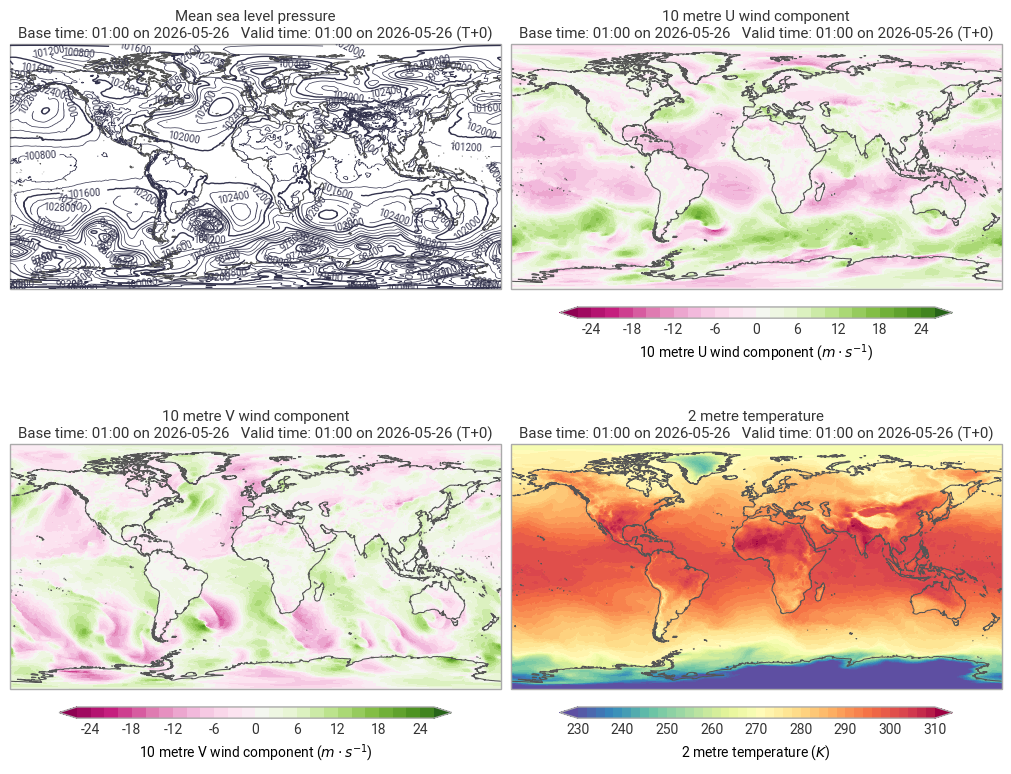

In [3]:
ekp.geo.plot(data)

The fieldlist is ordered the same way as the `param` string in the request (`151/165/166/167`),
so we can unpack it directly into named variables.

In [4]:
msl, wind_u, wind_v, t2m = data

### Visualisation

Climate DT data is stored on a **HEALPix** grid - an equal-area hierarchical tiling . Unlike regular latitude-longitude grids, each cell covers the same solid angle on the sphere, which avoids problems like polar over-sampling.

With earthkit-plots, the `grid_cells` method renders the actual grid polygons rather than interpolating to pixels, so you can see the cell shapes directly (this works with other grids too - not just HEALPix!). We can pass `style="auto"` to pick the colour scale automatically from the field metadata, and `.borders()` to add country borders as a layer on top. We can also pass a named domain - in this case "Europe", to automatically show the data on that domain with a suitable projection.

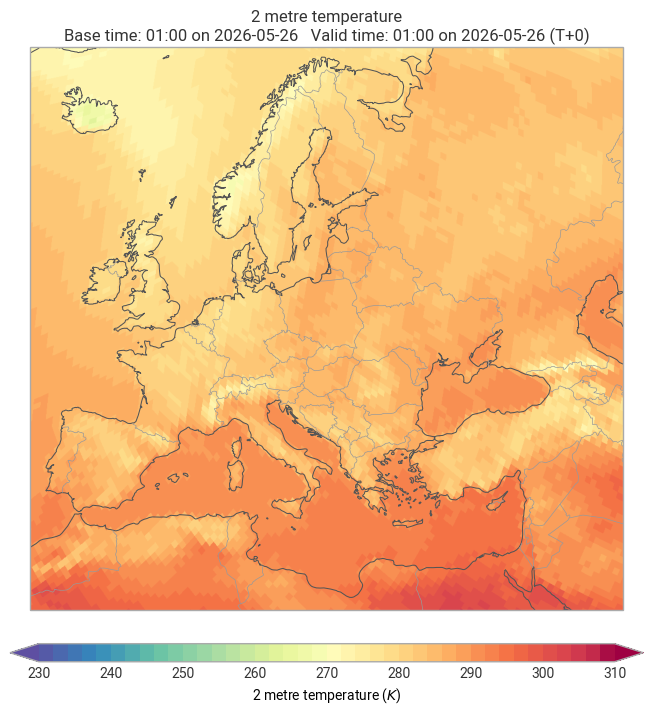

In [5]:
ekp.geo.grid_cells(t2m, domain="Europe", style="auto").borders()

`ekp.geo.plot` also accepts multiple fields.  Passing `t2m` and `msl` together renders temperature
as a filled background and mean-sea-level pressure as contours. The titles and labels are also updated automatically.

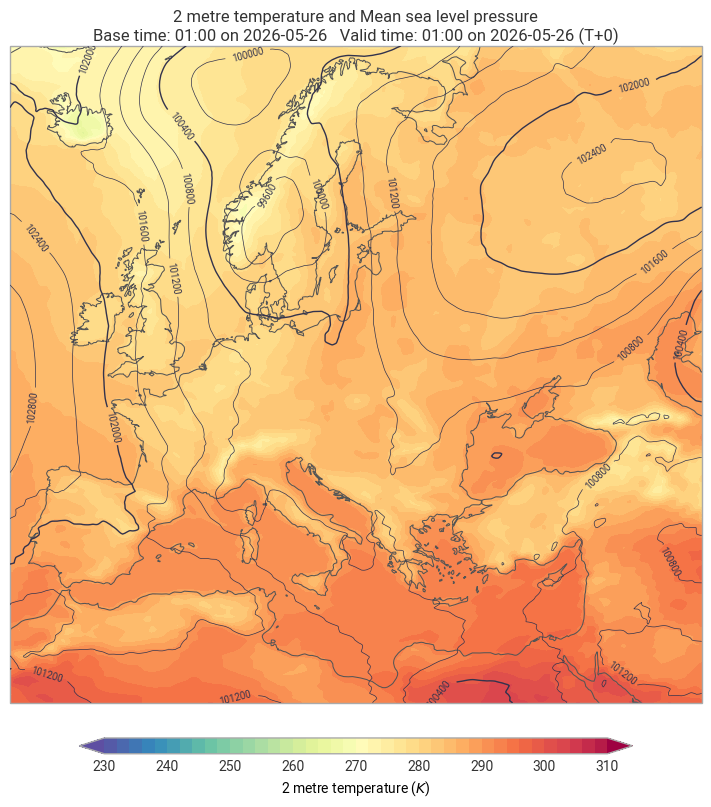

In [6]:
ekp.geo.plot(t2m, msl, domain="Europe")

### Going a bit deeper

While the high-level `ekp.geo` methods make it quick and easy to produce a map, the `ekp.Map` class gives you fine-grained control over every layer. This makes it easier to provide things like per-layer styles, units, labels etc.

In the map below, we plot temperature, pressure and wind speed and direction all on the same plot.

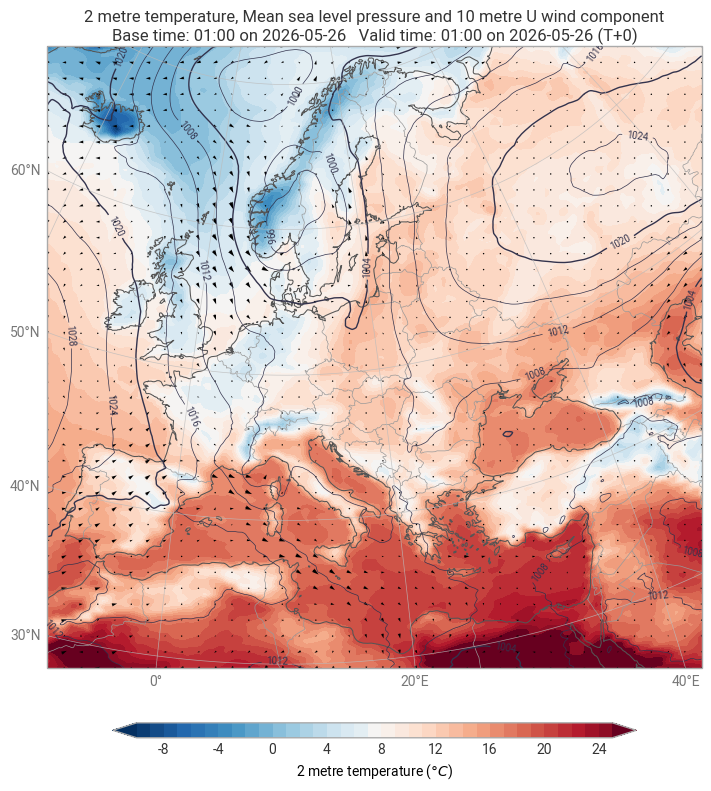

In [7]:
chart = ekp.Map(domain="Europe")

chart.plot(t2m, units="celsius", colors="RdBu_r", levels=range(-10, 26))
chart.plot(msl, units="hPa")
chart.legend()

chart.quiver(wind_u, wind_v)

chart.borders()
chart.coastlines()
chart.gridlines()

chart.title()

chart.show()

### Regridding

It's often very useful to regrid from one grid to another - whether for inter-model comparison, visualisation, or compatibility with tools.

earthkit-geo makes this process quick and easy, supporting any-to-any regridding between HEALPix, Gaussian, ORCA, ICON and regular latitude-longitude grids. In this example, let's regrid to a 0.5 degree regular latitude-longitude grid.

In [8]:
regular_ll = ekg.regrid(t2m, out_grid=[0.5, 0.5])
regular_ll

number_of_values,259920
array_type,ndarray
array_dtype,float64
variable,2t
standard_name,air_temperature
long_name,2 metre temperature
units,kelvin
chem_variable,None
valid_datetime,2026-05-26 01:00:00
base_datetime,2026-05-26 01:00:00
step,0:00:00


Now let's compare the grids side-by-side. `ekp.Figure` lets you arrange multiple map panels in a grid layout.  This comparison panel shows the same temperature field on both grids over France and Spain, making the hexagonal HEALPix cells and the rectangular lat-lon cells visually obvious at this zoom level.

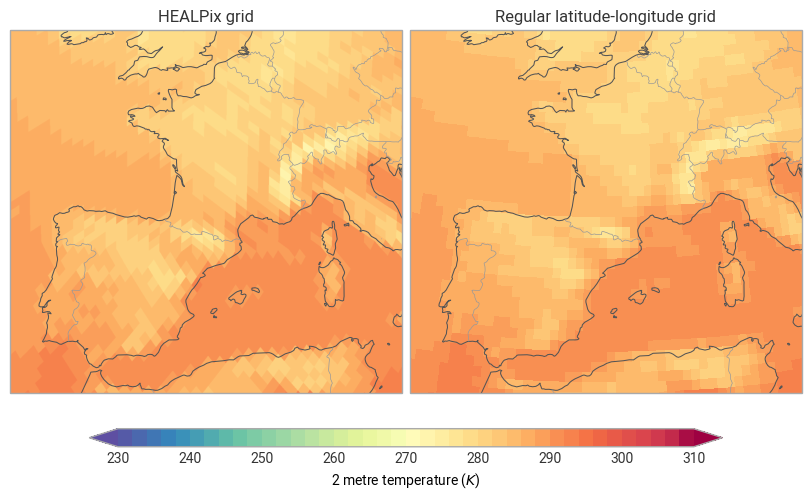

In [9]:
fig = ekp.Figure(domain=["France", "Spain"], rows=1, columns=2)

healpix_plot = fig.add_map()
healpix_plot.grid_cells(t2m, style="auto")
healpix_plot.title("HEALPix grid")

regular_ll_plot = fig.add_map()
regular_ll_plot.grid_cells(regular_ll, style="auto")
regular_ll_plot.title("Regular latitude-longitude grid")

fig.coastlines()
fig.borders()
fig.legend()

fig.show()

### Exercises

1. Try regridding the same 2m temperature data to a higher (e.g. 0.1 degrees) or lower (e.g. 1 degrees) resolution, and plot it side-by-side with the original HEALPix grid.

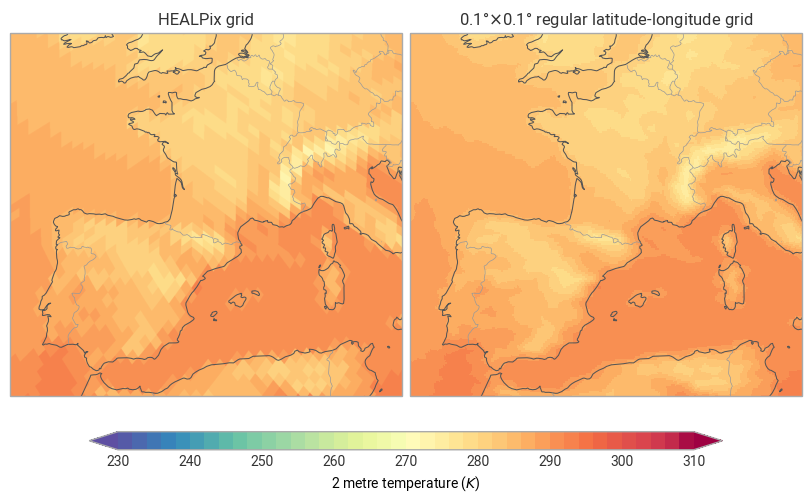

In [10]:
GRID = [0.1, 0.1]

t2m_0p1 = ekg.regrid(t2m, out_grid=GRID)

fig = ekp.Figure(domain=["France", "Spain"], rows=1, columns=2)

healpix_plot = fig.add_map()
healpix_plot.grid_cells(t2m, style="auto")
healpix_plot.title("HEALPix grid")

regular_ll_plot = fig.add_map()
regular_ll_plot.grid_cells(t2m_0p1, style="auto")
regular_ll_plot.title(rf"{GRID[0]}°$\times${GRID[1]}° regular latitude-longitude grid")

fig.coastlines()
fig.borders()
fig.legend()

fig.show()